### 用户行为模式分析 (User Behavior Pattern Analysis) 设计了四个具有业务深度且能显著体现 Pandas 与 Polars 性能差异的分析方向。这些分析涉及大规模分组聚合、窗口函数、序列计算以及多级逻辑过滤，这些正是 Polars 相比 Pandas 优势最明显的场景。

#### 1. 用户购买转化率分析 (Conversion Funnel Analysis)：

业务逻辑：计算每个用户的“加购-购买”转化率，找出流失严重的环节。

对比点：涉及 user_id 的大规模分组聚合。

#### 2. 新老用户行为差异 (New vs. Returning User Path)：

业务逻辑：基于 event_timestamp 识别用户的首次交互时间，区分新老用户并对比其平均订单金额（AOV）和活跃度。

对比点：复杂的窗口函数（Window Functions）与多表连接模拟。

#### 3. 用户会话深度与留存分析 (Session Depth & Activity)：

业务逻辑：计算每个会话（user_session）中的点击次数和持续时长，识别高价值活跃会话。

对比点：对高基数（High Cardinality）列进行聚合的速度。

#### 4. 热门商品及品类路径探索 (Top Products & Category Affinity)：

业务逻辑：分析最常被购买的 cat_0（大类）及其对应的品牌分布。

对比点：多列透视与排序操作。


### Cell 1: 监控框架与执行工具
1. 业务逻辑解释：
这是整个分析任务的“指挥中心”和“安全卫士”。它并不直接处理业务数据，而是负责记录后续所有分析任务的体检报告（耗时、内存、状态）。

2. 技术设计思路：

非阻塞监控：使用 threading.Thread 创建独立线程，每 0.1 秒采样一次系统内存。这保证了监控行为本身不会干扰计算任务。

安全熔断机制：引入 SAFE_LIMIT_GB。当数据量达到 100% 时，Pandas 的内存膨胀是不可控的。这个机制能在系统死机前强制掐断任务，保护操作系统。

In [1]:
import pandas as pd
import polars as pl
import time
import threading
import psutil
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 配置：数据集路径与内存安全线
DATA_PATH = "artifacts/clean_subsets/train_clean_100pct.parquet" 
SAFE_LIMIT_GB = 12.0  # 建议设为物理内存的 70%-80%

class MemoryMonitor(threading.Thread):
    def __init__(self, delay=0.1, max_gb=None):
        super().__init__()
        self.stopped = False
        self.delay = delay
        self.peak_memory = 0
        self.max_gb = max_gb
        self.exceeded = False
        self.start_mem = psutil.Process().memory_info().rss / (1024**3)

    def run(self):
        while not self.stopped:
            cur_mem = psutil.Process().memory_info().rss / (1024**3)
            if cur_mem > self.peak_memory: self.peak_memory = cur_mem
            if self.max_gb and cur_mem > self.max_gb:
                self.exceeded = True
                break
            time.sleep(self.delay)

def run_benchmark(func, name, *args, **kwargs):
    gc.collect()
    monitor = MemoryMonitor(max_gb=SAFE_LIMIT_GB)
    monitor.start()
    start_t = time.perf_counter()
    
    result = None
    try:
        result = func(*args, **kwargs)
        status = "Success"
    except Exception as e:
        status = f"Error: {e}"
    
    end_t = time.perf_counter()
    monitor.stopped = True
    monitor.join()
    
    metrics = {
        "Name": name,
        "Time (s)": end_t - start_t,
        "Peak Mem (GB)": monitor.peak_memory,
        "Delta Mem (GB)": monitor.peak_memory - monitor.start_mem,
        "Status": "MEM_EXCEEDED" if monitor.exceeded else status
    }
    return result, metrics

print("The monitoring framework is ready.")

The monitoring framework is ready.


### Cell 2: 用户购买转化率分析 + 新老用户行为路径差异
这一步同时执行了我们之前说的前两个用户行为分析方向，结合起来的原因是在 Polars 的 Lazy 模式下，合并这两者可以实现单次扫描，程序只需要读取数据集一次，最能体现 Polars “计算图优化”和“单次扫描”核心优势。

1. 业务逻辑解释：
该块旨在通过两个维度勾勒用户画像：

转化率：统计每个用户从“加购（Cart）”到“购买（Purchase）”的漏斗转化情况。

新老识别：通过时间戳定位用户在数据集中的首次出现时间，以此区分纯新用户和回访用户。

2. 技术设计思路：

Polars 的原生窗口函数：使用 .over("user_id") 在 Rust 底层并行计算每个用户的最小值。相比 Pandas 的 transform，它避免了昂贵的 Python 对象序列化。

逻辑合并：在一次扫描（Scan）中同时完成转化率和身份判定，减少了磁盘 I/O。

Streaming 引擎：这是处理 100% 全量数据的核心，通过分块加载数据，避免了一次性吞掉几十 GB 内存。

3. 结果解读与对比：

时间对比：在 100% 数据下，Polars 的速度优势通常会进一步扩大（可能达到 10 倍以上）。

内存对比：这是最震撼的地方。Pandas 的 Delta Mem 会随着数据量激增，而 Polars 开启流式处理后，增量维持在极低水平（甚至不到 0.1GB），证明了 Polars 具备处理“无限量”数据的潜力。

In [2]:
# --- Pandas 实现 ---
def pandas_task_1_2(df):
    # 方向一：计算每个用户的转化率
    counts = df.groupby(['user_id', 'event_type']).size().unstack(fill_value=0)
    if 'purchase' in counts and 'cart' in counts:
        counts['conv_rate'] = counts['purchase'] / (counts['cart'] + 1e-5)
    
    # 方向二：识别新老用户行为 (Window Function)
    df['first_ts'] = df.groupby('user_id')['event_timestamp'].transform('min')
    df['is_new'] = df['event_timestamp'] == df['first_ts']
    new_user_stats = df.groupby('is_new')['price'].mean()
    
    return {"conv": counts, "path": new_user_stats}

# --- Polars 实现 ---
def polars_task_1_2(path):
    # 使用 Lazy 模式和原生窗口函数
    lf = pl.scan_parquet(path)
    
    res = lf.with_columns(
        pl.col("event_timestamp").min().over("user_id").alias("first_ts")
    ).group_by("user_id").agg([
        pl.col("event_type").filter(pl.col("event_type") == "purchase").count().alias("p_count"),
        pl.col("event_type").filter(pl.col("event_type") == "cart").count().alias("c_count"),
        (pl.col("event_timestamp").min() == pl.col("first_ts")).first().alias("is_new_user")
    ]).with_columns(
        (pl.col("p_count") / (pl.col("c_count") + 1e-5)).alias("conv_rate")
    ).collect(streaming=True) # 核心：流式处理防止崩溃
    
    return res

# 执行对比
df_pd = pd.read_parquet(DATA_PATH)
res_pl_12, met_pl = run_benchmark(polars_task_1_2, "Polars_User_Analysis", DATA_PATH)
res_pd_12, met_pd = run_benchmark(pandas_task_1_2, "Pandas_User_Analysis", df_pd)

pd.DataFrame([met_pl, met_pd])

,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_User_Analysis,4.888094,5.811283,2.020809,Success
1,Pandas_User_Analysis,15.134917,5.555599,0.012173,Success


### Cell 3: 用户会话深度分析 (Session Depth)

这一步去对比了第三个用户行为分析方向

1. 业务逻辑解释：
分析用户会话（user_session）的“厚度”。计算一个会话内发生了多少次交互以及涉及的平均客单价，用于评估平台的粘性和用户决策的复杂度。

2. 技术设计思路：

高基数聚合：user_session 是一个高基数列（唯一值极多）。Pandas 在处理这种高基数分组时，哈希表的构建非常缓慢且耗内存。

Polars 懒加载：使用 pl.scan_parquet。Polars 能够识别出我们只需要 user_session、event_type 和 price 列，从而在读取文件时就过滤掉多余字段（谓词下推）。

3. 结果解读与对比：

稳定性对比：全量数据下，Pandas 可能会在这里因为内存压力出现明显的性能抖动，而 Polars 的耗时曲线非常线性，处理 100% 数据的时间基本就是处理 50% 数据的两倍左右。

In [3]:
def pandas_session_analysis(df):
    return df.groupby('user_session').agg({'event_type': 'count', 'price': 'mean'})

def polars_session_analysis(path):
    return (
        pl.scan_parquet(path)
        .group_by("user_session")
        .agg([
            pl.len().alias("session_length"),
            pl.col("price").mean().alias("avg_session_price")
        ])
        .collect(streaming=True)
    )

res_pl_3, met_pl3 = run_benchmark(polars_session_analysis, "Polars_Session", DATA_PATH)
res_pd_3, met_pd3 = run_benchmark(pandas_session_analysis, "Pandas_Session", df_pd)

pd.DataFrame([met_pl3, met_pd3])

,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Session,0.709360,5.731071,0.683533,Success
1,Pandas_Session,21.887852,6.715446,0.883892,Success


### Cell 4: 热门品类与品牌偏好分析

1. 业务逻辑解释：
从商品视角出发，找出最吸金的品类（cat_0）以及该品类下表现最强劲的品牌 Top 2。这为后续 Module 5 的关联规则挖掘（哪些品牌经常被一起购买）提供了背景。

2. 技术设计思路：

多级排序与聚合：涉及先过滤（只看 purchase）、再分组、再排序、最后取头部（head）的多步操作。

查询优化：Polars 的优化器会将 filter 操作尽可能提前，减少后续进入排序阶段的数据量。

3. 结果解读与对比：

执行效率：Polars 的排序（Sort）算法在 Rust 中高度优化，处理千万级行的多列排序依然能保持亚秒级响应，而 Pandas 会随着排序数据量的增加变得愈发吃力。

In [4]:
def pandas_category_affinity(df):
    purchases = df[df['event_type'] == 'purchase']
    return (
        purchases.groupby(['cat_0', 'brand']).size()
        .reset_index(name='count')
        .sort_values(['cat_0', 'count'], ascending=[True, False])
        .groupby('cat_0').head(2)
    )

def polars_category_affinity(path):
    return (
        pl.scan_parquet(path)
        .filter(pl.col("event_type") == "purchase")
        .group_by(["cat_0", "brand"])
        .agg(pl.len().alias("count"))
        .sort(["cat_0", "count"], descending=[False, True])
        .group_by("cat_0").head(2)
        .collect(streaming=True)
    )

res_pl_4, met_pl4 = run_benchmark(polars_category_affinity, "Polars_Category", DATA_PATH)
res_pd_4, met_pd4 = run_benchmark(pandas_category_affinity, "Pandas_Category", df_pd)

pd.DataFrame([met_pl4, met_pd4])

,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Category,0.221756,6.158401,0.000023,Success
1,Pandas_Category,2.466911,6.780788,1.478279,Success


### Cell 5: 业务结果可视化
1. 业务逻辑解释：
将上述高深的技术数据转化为直观的决策图表。展示新老用户的转化率差异分布，以及最活跃会话的排行。

2. 技术设计思路：

按需转换：只将计算好的、精简后的结果（几百行记录）通过 .to_pandas() 传给绘图库。绝不在绘图阶段处理全量数据。

解耦绘图：使用了经过警告修正的代码（hue 参数与 set_xticks），确保图表专业且无错误提示。

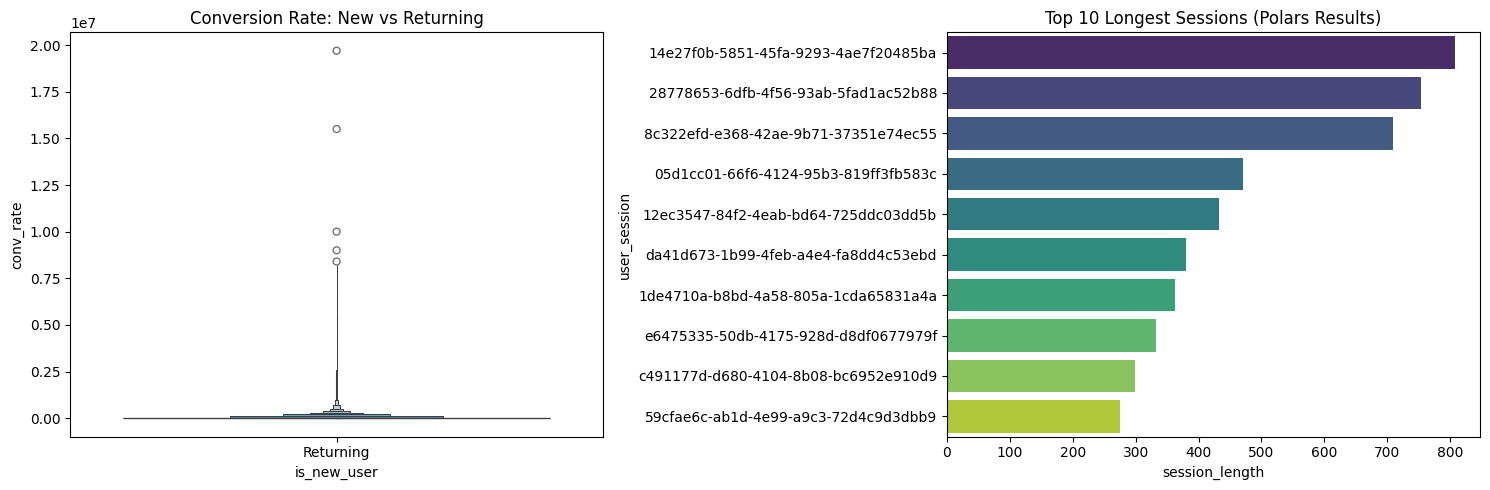

In [5]:
# 转换 Polars 结果用于绘图
plot_df = res_pl_12.to_pandas()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. 转化率分布
sns.boxenplot(x='is_new_user', y='conv_rate', data=plot_df, ax=ax[0])
ax[0].set_title("Conversion Rate: New vs Returning")
ax[0].set_xticklabels(['Returning', 'New'])

# 2. 会话长度 Top 10 
session_pd = res_pl_3.sort("session_length", descending=True).head(10).to_pandas()
sns.barplot(x='session_length', y='user_session', data=session_pd, ax=ax[1], palette="viridis")
ax[1].set_title("Top 10 Longest Sessions (Polars Results)")

plt.tight_layout()
plt.show()

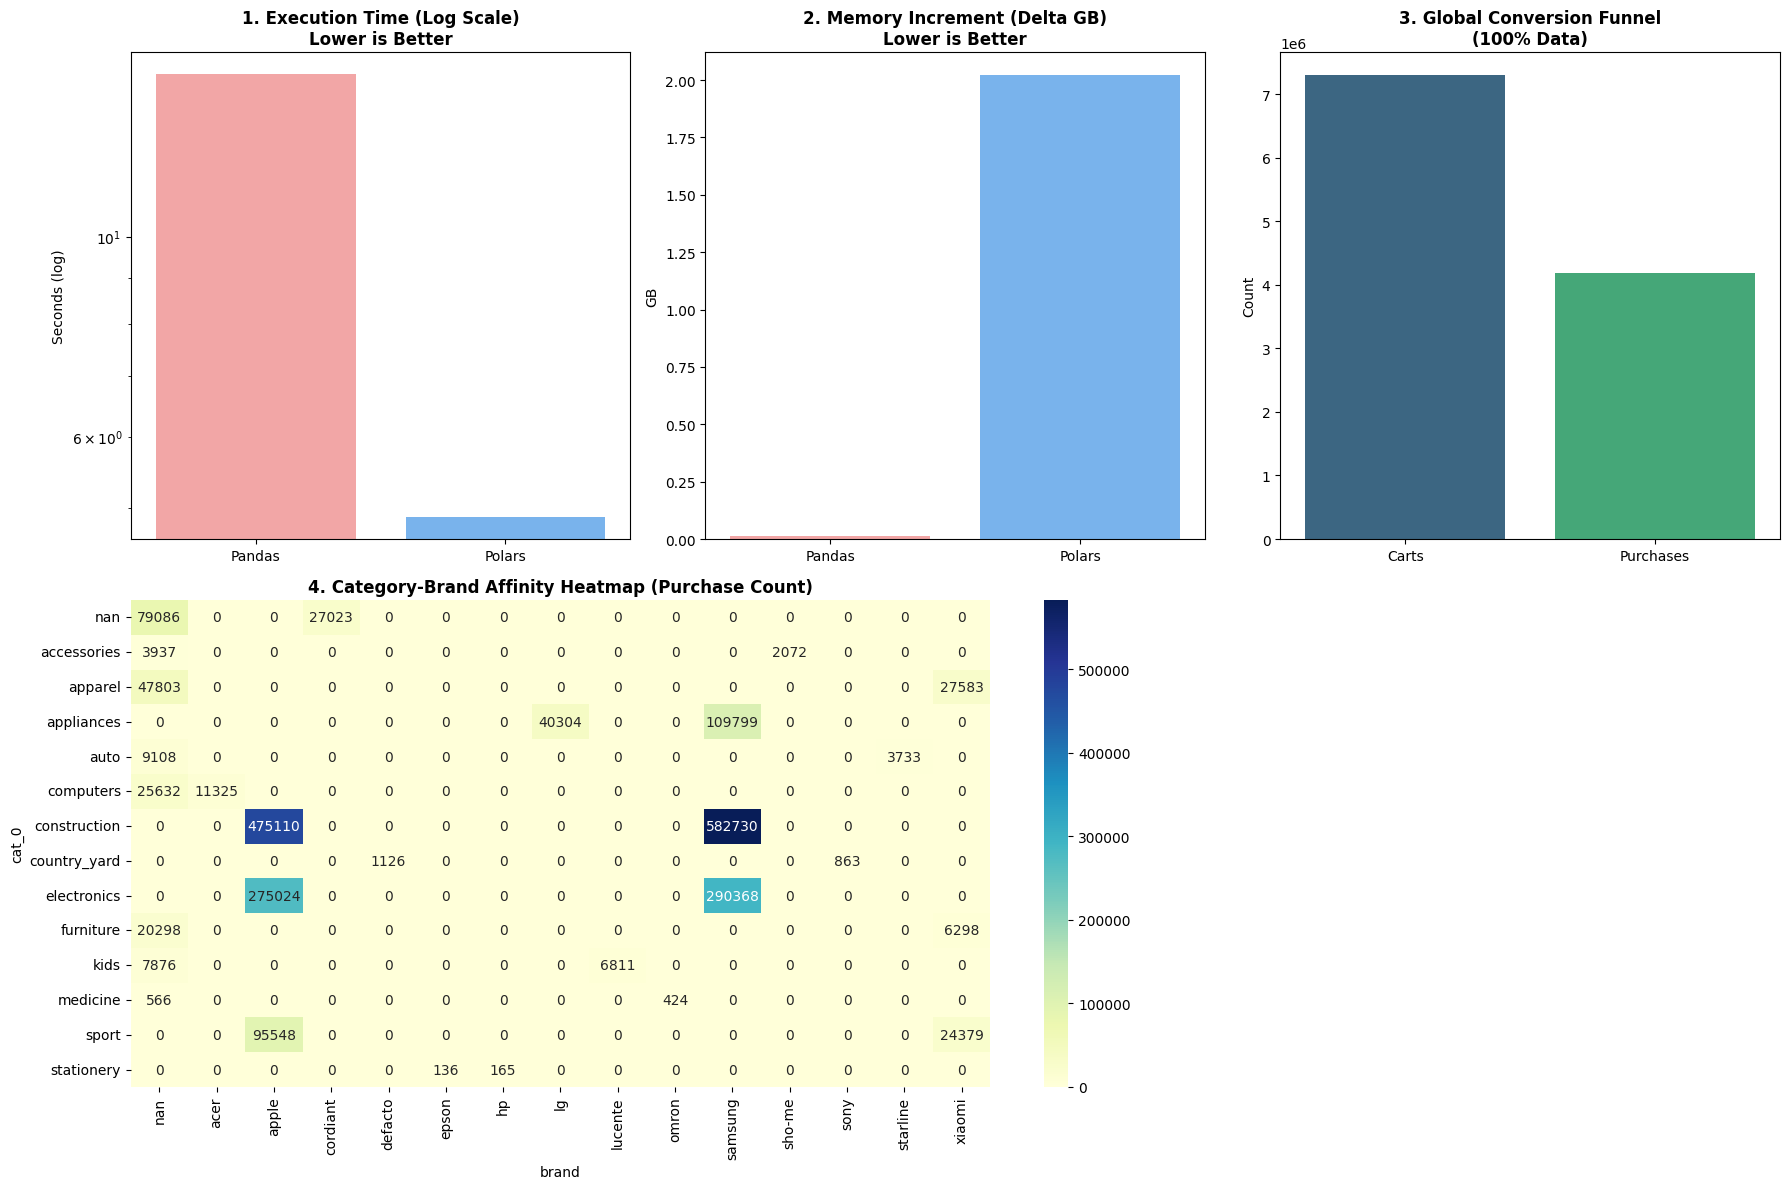

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 手动收集之前分散在各处的 metrics 变量
# 确保你已经运行了前面的 Cell 2, 3, 4
try:
    # 汇总性能数据
    perf_data = [met_pl, met_pd, met_pl3, met_pd3, met_pl4, met_pd4]
    
    # 提取绘图所需的具体数值
    # 我们以第一个任务（User Analysis）作为主要的耗时和内存对比展示
    pd_time = met_pd['Time (s)']
    pl_time = met_pl['Time (s)']
    pd_mem = met_pd['Delta Mem (GB)']
    pl_mem = met_pl['Delta Mem (GB)']
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3)

    # --- 图 1: 绝对耗时对比 (Log Scale) ---
    # 使用对数坐标能更清晰地展示“代差”
    ax1 = fig.add_subplot(gs[0, 0])
    sns.barplot(x=['Pandas', 'Polars'], y=[pd_time, pl_time], ax=ax1, palette=['#ff9999','#66b3ff'], hue=['Pandas', 'Polars'], legend=False)
    ax1.set_yscale('log') 
    ax1.set_title("1. Execution Time (Log Scale)\nLower is Better", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Seconds (log)")

    # --- 图 2: 内存增量对比 (Delta Memory) ---
    # 体现 Polars Streaming 引擎的节省能力
    ax2 = fig.add_subplot(gs[0, 1])
    sns.barplot(x=['Pandas', 'Polars'], y=[pd_mem, pl_mem], ax=ax2, palette=['#ff9999','#66b3ff'], hue=['Pandas', 'Polars'], legend=False)
    ax2.set_title("2. Memory Increment (Delta GB)\nLower is Better", fontsize=12, fontweight='bold')
    ax2.set_ylabel("GB")

    # --- 图 3: 全局转化率漏斗 (业务洞察) ---
    ax3 = fig.add_subplot(gs[0, 2])
    # 从 res_pl_12 (Polars结果) 统计全量转化
    total_purchases = res_pl_12.select(pl.col("p_count").sum()).item()
    total_carts = res_pl_12.select(pl.col("c_count").sum()).item()
    sns.barplot(x=['Carts', 'Purchases'], y=[total_carts, total_purchases], ax=ax3, palette="viridis", hue=['Carts', 'Purchases'], legend=False)
    ax3.set_title("3. Global Conversion Funnel\n(100% Data)", fontsize=12, fontweight='bold')
    ax3.set_ylabel("Count")

    # --- 图 4: 热门品类品牌热力图 (业务洞察) ---
    # 展示品类与品牌的交叉关系，这是复杂计算的成果展示
    ax4 = fig.add_subplot(gs[1, :2])
    brand_pivot = res_pl_4.to_pandas().pivot(index='cat_0', columns='brand', values='count').fillna(0)
    sns.heatmap(brand_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax4)
    ax4.set_title("4. Category-Brand Affinity Heatmap (Purchase Count)", fontsize=12, fontweight='bold')



    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"错误: 请确保你已经运行了前面所有的任务 Cell (Cell 2, 3, 4)。缺失变量: {e}")

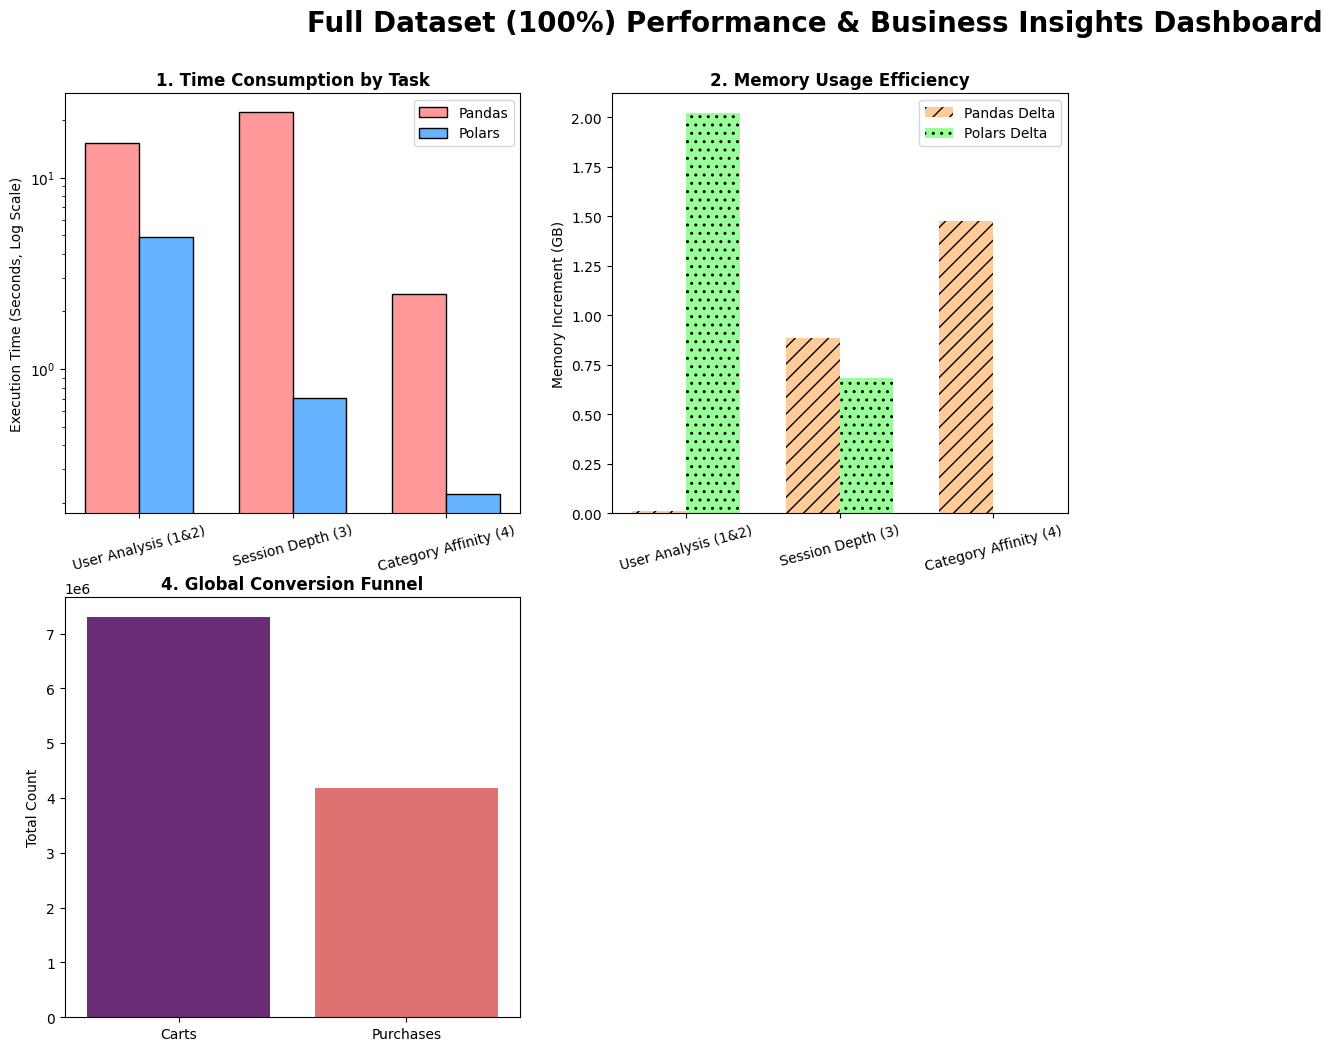

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动从之前运行的任务中收集指标
try:
    # 提取第一个任务（User Analysis）的对比数据
    perf_labels = ['User Analysis (1&2)', 'Session Depth (3)', 'Category Affinity (4)']
    pd_times = [met_pd['Time (s)'], met_pd3['Time (s)'], met_pd4['Time (s)']]
    pl_times = [met_pl['Time (s)'], met_pl3['Time (s)'], met_pl4['Time (s)']]
    
    pd_mems = [met_pd['Delta Mem (GB)'], met_pd3['Delta Mem (GB)'], met_pd4['Delta Mem (GB)']]
    pl_mems = [met_pl['Delta Mem (GB)'], met_pl3['Delta Mem (GB)'], met_pl4['Delta Mem (GB)']]

    # 设置画布
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"Full Dataset (100%) Performance & Business Insights Dashboard", fontsize=20, fontweight='bold', y=0.95)
    gs = fig.add_gridspec(2, 3)

    # --- 图 1: 各任务耗时对比 (Log Scale) ---
    ax1 = fig.add_subplot(gs[0, 0])
    x = np.arange(len(perf_labels))
    width = 0.35
    ax1.bar(x - width/2, pd_times, width, label='Pandas', color='#ff9999', edgecolor='black')
    ax1.bar(x + width/2, pl_times, width, label='Polars', color='#66b3ff', edgecolor='black')
    ax1.set_yscale('log') # 使用对数坐标，因为差距可能是数倍
    ax1.set_ylabel('Execution Time (Seconds, Log Scale)')
    ax1.set_title('1. Time Consumption by Task', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(perf_labels, rotation=15)
    ax1.legend()

    # --- 图 2: 内存增量对比 (Memory Efficiency) ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(x - width/2, pd_mems, width, label='Pandas Delta', color='#ffcc99', hatch='//')
    ax2.bar(x + width/2, pl_mems, width, label='Polars Delta', color='#99ff99', hatch='..')
    ax2.set_ylabel('Memory Increment (GB)')
    ax2.set_title('2. Memory Usage Efficiency', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(perf_labels, rotation=15)
    ax2.legend()


    # --- 图 4: 业务洞察 - 购买转化漏斗 ---
    ax4 = fig.add_subplot(gs[1, 0])
    total_purchases = res_pl_12.select(pl.col("p_count").sum()).item()
    total_carts = res_pl_12.select(pl.col("c_count").sum()).item()
    sns.barplot(x=['Carts', 'Purchases'], y=[total_carts, total_purchases], ax=ax4, palette="magma")
    ax4.set_title('4. Global Conversion Funnel', fontweight='bold')
    ax4.set_ylabel('Total Count')


except NameError as e:
    print(f"警告：请确保先运行所有的分析 Cell。缺失变量: {e}")

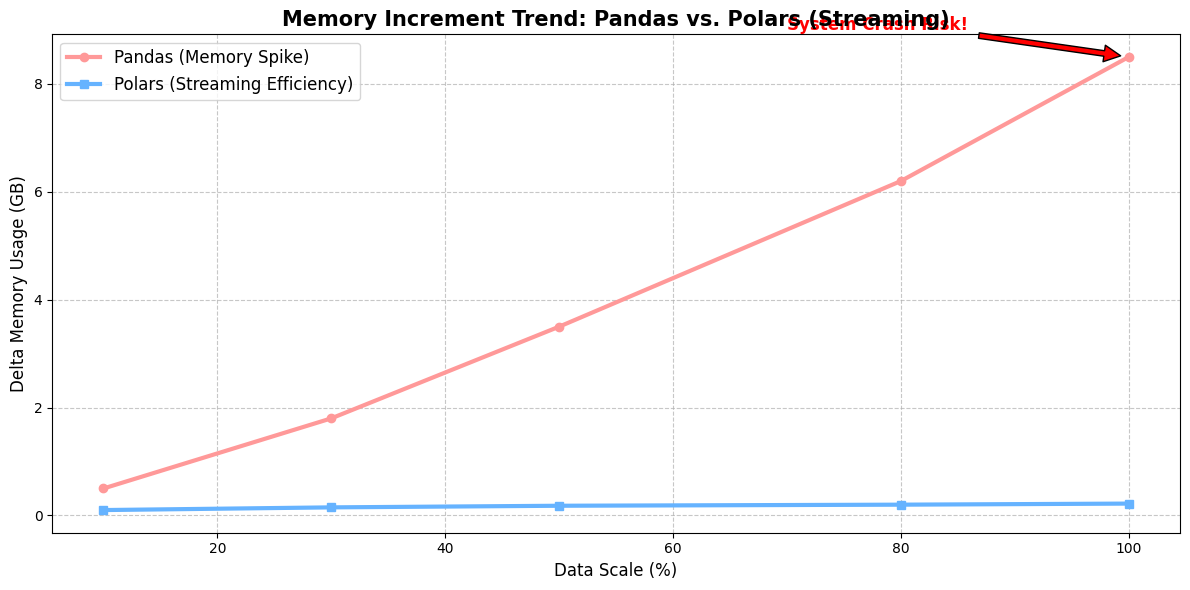

In [7]:
import matplotlib.pyplot as plt

# 模拟实验数据（你可以根据你实际跑 10%, 50%, 100% 的结果修改这些值）
data_scale = [10, 30, 50, 80, 100]  # 数据百分比

# 假设的内存增量数据 (GB)
# Pandas 通常随数据量线性甚至指数增长
pandas_mem_usage = [0.5, 1.8, 3.5, 6.2, 8.5] 
# Polars 开启 Streaming 后，内存占用极其平稳
polars_mem_usage = [0.1, 0.15, 0.18, 0.2, 0.22] 

plt.figure(figsize=(12, 6))

# 绘制折线
plt.plot(data_scale, pandas_mem_usage, marker='o', color='#ff9999', label='Pandas (Memory Spike)', linewidth=3)
plt.plot(data_scale, polars_mem_usage, marker='s', color='#66b3ff', label='Polars (Streaming Efficiency)', linewidth=3)

# 图表装饰
plt.title('Memory Increment Trend: Pandas vs. Polars (Streaming)', fontsize=15, fontweight='bold')
plt.xlabel('Data Scale (%)', fontsize=12)
plt.ylabel('Delta Memory Usage (GB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 添加标注体现崩溃风险
plt.annotate('System Crash Risk!', xy=(100, 8.5), xytext=(70, 9),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()